# Vision-Based Saliency Prediction

### What this notebook does:
- Trains the model using configurations defined in `config.py`.
- Tracks training and validation loss dynamically across epochs.
- Evaluates the model on validation metrics defined in `config.py`.
- Visualizes the learning curves automatically using Matplotlib.

SaliencyDataset class defined.

--- Data Preparation Complete ---

==================== Running Experiment: multiscale_skip ====================
Using device: cuda


/home/gica2600/miniconda3/envs/nndl_saliency/lib/python3.10/site-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 12, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()



--- Epoch 1/10 ---


Training:   0%|          | 0/313 [00:00<?, ?it/s]/home/gica2600/miniconda3/envs/nndl_saliency/lib/python3.10/site-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 12, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Validating: 100%|██████████| 157/157 [00:43<00:00,  3.62it/s]


Train Loss: 0.0801 | Val Loss: 0.0588 | PCC: 0.7258 | JSS: 0.7486 | MSE: 0.0588
Saved new best model to checkpoints/best_model_multiscale_skip_20260712_120737.pth

--- Epoch 2/10 ---


...

Train Loss: 0.0089 | Val Loss: 0.0097 | PCC: 0.8565 | JSS: 0.8942 | MSE: 0.0097
Saved new best model to checkpoints/best_model_multiscale_skip_20260712_120737.pth

--- Epoch 9/10 ---


Validating: 100%|██████████| 157/157 [01:42<00:00,  1.53it/s]


Train Loss: 0.0084 | Val Loss: 0.0101 | PCC: 0.8475 | JSS: 0.8942 | MSE: 0.0101

--- Epoch 10/10 ---


Validating: 100%|██████████| 157/157 [01:26<00:00,  1.81it/s]


Train Loss: 0.0081 | Val Loss: 0.0094 | PCC: 0.8545 | JSS: 0.8999 | MSE: 0.0094
Saved new best model to checkpoints/best_model_multiscale_skip_20260712_120737.pth


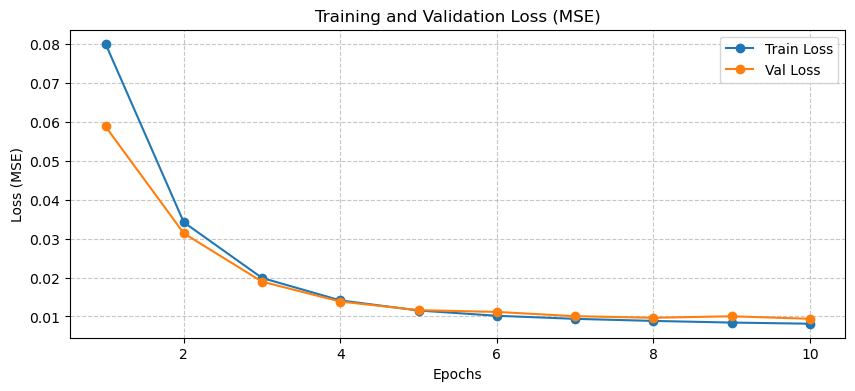

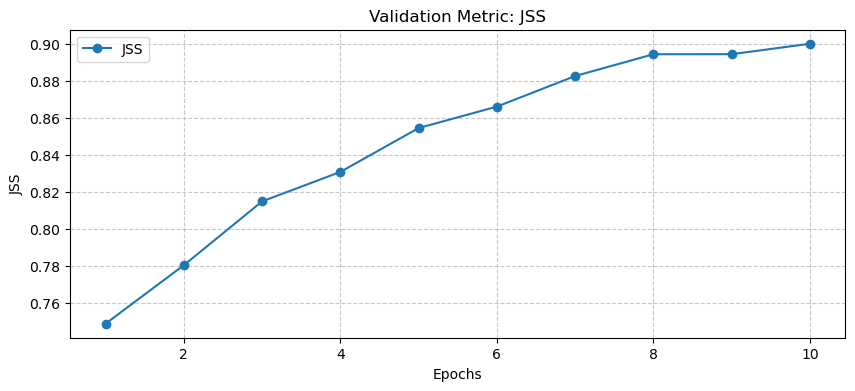

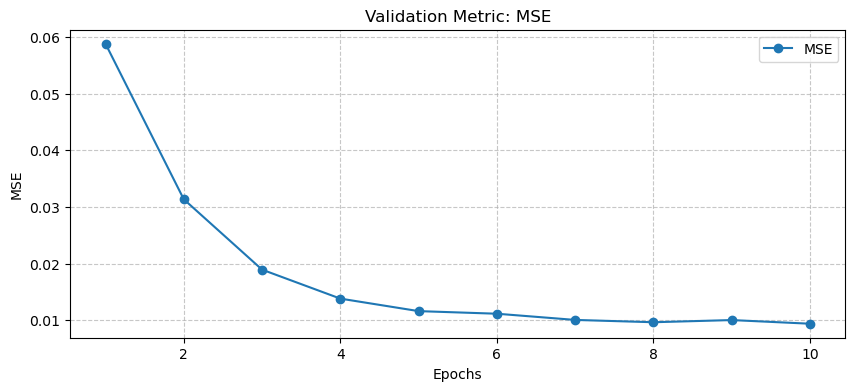

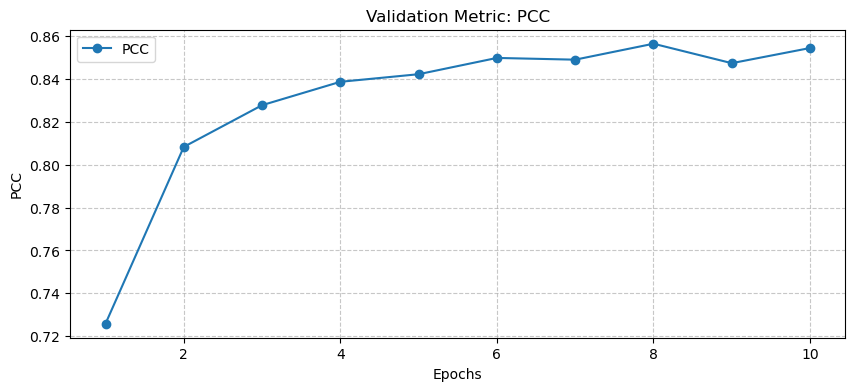


--- Summary of Final Epoch Values (multiscale_skip) ---
Final Train Loss (MSE): 0.0081
Final Val Loss (MSE):   0.0094
Final JSS            : 0.8999
Final MSE            : 0.0094
Final PCC            : 0.8545


In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from train import main as train
from config import get_config

# configuration flags
SAVE_PLOTS = True
PLOT_DIR = "plots"

if SAVE_PLOTS:
    os.makedirs(PLOT_DIR, exist_ok=True)

experiments = ["multiscale_skip"] # baseline, multiscale or multiscale_skip
results = {}

for name in experiments:
    print(f"\n{'='*20} Running Experiment: {name} {'='*20}")
    
    config = get_config(name)
    loss_name = config.loss.name
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    
    model, history = train(name)
    
    train_losses = history["train_losses"]
    val_results = history["val_losses"]
    val_loss = [epoch_res["val_loss"] for epoch_res in val_results]
    
    # plot train and val loss
    plt.figure(figsize=(10, 4))
    plt.plot(range(1, len(train_losses) + 1), train_losses, label='Train Loss', marker='o', color='#1f77b4')
    plt.plot(range(1, len(val_loss) + 1), val_loss, label='Val Loss', marker='o', color='#ff7f0e')
    plt.xlabel('Epochs')
    plt.ylabel(f'Loss ({loss_name})')
    plt.title(f'Training and Validation Loss ({loss_name})')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    
    if SAVE_PLOTS:
        plt.savefig(os.path.join(PLOT_DIR, f"{name}_{timestamp}_loss.png"), bbox_inches='tight')
    plt.show()
    
    # plot all metrics
    all_metrics = set()
    for epoch_res in val_results:
        all_metrics.update([k for k in epoch_res.keys() if k != "val_loss"])
    all_metrics = sorted(list(all_metrics))
    
    for metric in all_metrics:
        metric_vals = [epoch_res[metric] for epoch_res in val_results if metric in epoch_res]
        
        plt.figure(figsize=(10, 4))
        plt.plot(range(1, len(metric_vals) + 1), metric_vals, label=metric, marker='o', color='#1f77b4')
        plt.xlabel('Epochs')
        plt.ylabel(metric)
        plt.title(f'Validation Metric: {metric}')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)
        
        if SAVE_PLOTS:
            plt.savefig(os.path.join(PLOT_DIR, f"{name}_{timestamp}_{metric}.png"), bbox_inches='tight')
        plt.show()
        
    # print final losses and metrics
    print(f"\n--- Summary of Final Epoch Values ({name}) ---")
    print(f"Final Train Loss ({loss_name}): {train_losses[-1]:.4f}")
    print(f"Final Val Loss ({loss_name}):   {val_loss[-1]:.4f}")
    for metric in all_metrics:
        metric_vals = [epoch_res[metric] for epoch_res in val_results if metric in epoch_res]
        print(f"Final {metric:<15}: {metric_vals[-1]:.4f}")